# GSB 5544 — Topic 7.1: Association Rules — SOLUTION
*Who gets played together? Finding "if this, then that" patterns in playlists*

## The next 20 minutes

| | Question | New tools | Where it lands in PA 7.1 |
|---|---|---|---|
| **1. Baskets** | What is a transaction, and how does a list of lists become a table of `True`/`False`? | `explode`, `crosstab` | parts 1 – 3 |
| **2. Support** | How common is an item — or a pair of items? | `.mean()` on booleans, `.all(axis=1)` | parts 4 – 5, 9 |
| **3. Confidence & lift** | If a playlist has A, how likely is B — and is that more than chance? | two formulas | parts 6 – 11 |
| **4. Mining** | How do we find *all* the good rules at once? | `apriori`, `association_rules` | parts 12 – 19 |

A grocery store asks "what sells with what?" A streaming service asks "who gets played with whom?" Same
question, same method: **association rules**. A rule looks like **{J. Cole} → {Kendrick Lamar}**: *playlists
that contain J. Cole tend to contain Kendrick Lamar too.* Our job is to measure how strong such a rule is.

In [1]:
import numpy as np
import pandas as pd
from plotnine import ggplot, aes, geom_col, coord_flip, labs
from mlxtend.frequent_patterns import apriori, association_rules

---
## 1. Transactions: playlists as baskets

**About the data.** The artists below are real — eight Latin artists and eight hip-hop artists — but the
**playlists are simulated** by the next cell, so that we know what patterns were planted and can check whether
the method finds them. Nothing here is a statement about real listening habits. Each simulated listener
has a taste (Latin, hip-hop, or mixed), picks a few artists accordingly, and Bad Bunny is added to most
playlists regardless of taste, and a handful of pairings are deliberately made more likely — for example,
listeners with J. Cole usually add Kendrick Lamar. *Run the cell;
you do not need to study it.*

In [2]:
LATIN = ["Bad Bunny", "J Balvin", "Karol G", "Shakira", "Rauw Alejandro", "Peso Pluma", "Daddy Yankee", "Rosalía"]
HIPHOP = ["Kendrick Lamar", "Drake", "J. Cole", "Travis Scott", "Cardi B", "Megan Thee Stallion", "Future", "Tyler, the Creator"]

rng = np.random.default_rng(5544)

def simulate_playlist():
    taste = rng.choice(["latin", "hiphop", "mixed"], p=[0.4, 0.4, 0.2])
    p_latin = {"latin": 0.45, "hiphop": 0.05, "mixed": 0.25}[taste]      # chance of including each Latin artist
    p_hiphop = {"latin": 0.05, "hiphop": 0.45, "mixed": 0.25}[taste]     # ... and each hip-hop artist
    artists = set(a for a in LATIN if rng.random() < p_latin) | set(a for a in HIPHOP if rng.random() < p_hiphop)
    if rng.random() < 0.75:                         artists.add("Bad Bunny")          # Bad Bunny is on most playlists, whatever the taste
    if "J. Cole" in artists and rng.random() < 0.7: artists.add("Kendrick Lamar")    # planted pairings
    if "Karol G" in artists and rng.random() < 0.6: artists.add("Shakira")
    if "Future" in artists and rng.random() < 0.6:  artists.add("Travis Scott")
    if "Cardi B" in artists and rng.random() < 0.6: artists.add("J Balvin")          # a planted cross-genre pairing
    if len(artists) < 2:                                                             # every playlist has at least 2 artists
        artists |= set(rng.choice(LATIN + HIPHOP, size=2, replace=False))
    return sorted(artists)

playlists = [simulate_playlist() for _ in range(400)]
len(playlists), playlists[:3]

(400,
 [['Bad Bunny', 'Daddy Yankee', 'Karol G', 'Shakira'],
  ['Daddy Yankee', 'Peso Pluma', 'Rosalía'],
  ['Bad Bunny',
   'Daddy Yankee',
   'J. Cole',
   'Karol G',
   'Shakira',
   'Travis Scott']])

`playlists` is a **list of lists**: one inner list per playlist (a *transaction* or *basket*), holding the
artists (*items*) in it. Playlists have different lengths — that is why this is not yet a table.

### From list of lists to one row per (playlist, artist)

The same two moves as PA 7.1: give each playlist an id, then `explode` the list so each artist gets its own row.

In [3]:
long = (pd.DataFrame({"artist": playlists})
          .assign(playlist_id=lambda d: d.index)
          .explode("artist")                     # one row per (playlist, artist)
          .reset_index(drop=True))
print(long.shape)
long.head(8)

(1952, 2)


,artist,playlist_id
0,Bad Bunny,0
1,Daddy Yankee,0
2,Karol G,0
3,Shakira,0
4,Daddy Yankee,1
5,Peso Pluma,1
6,Rosalía,1
7,Bad Bunny,2


### The one-hot table

Association-rule tools want **one row per transaction, one column per item**, with `True`/`False`.
`pd.crosstab` counts (playlist, artist) pairs; `> 0` turns the counts into `True`/`False`.

In [4]:
basket = pd.crosstab(long["playlist_id"], long["artist"]) > 0
print(basket.shape)
basket.iloc[:5, :6]

(400, 16)


artist,Bad Bunny,Cardi B,Daddy Yankee,Drake,Future,J Balvin
playlist_id,,,,,,
0,True,False,True,False,False,False
1,False,False,True,False,False,False
2,True,False,True,False,False,False
3,True,True,True,False,False,True
4,True,False,False,False,True,False


✅ **Checkpoint 1.** (a) What does one **row** of `basket` represent? One **column**? (b) `basket.shape` is
(400, 16) — where do the two numbers come from? (c) Why `> 0` rather than keeping the counts?

**Answer:** (a) A row is one playlist; a column is one artist; the cell says whether that artist is on that playlist.
(b) 400 simulated playlists and 16 distinct artists (8 Latin + 8 hip-hop). (c) Association rules ask *whether*
an item is in a basket, not how many times; `apriori` expects a boolean table, and booleans also make the
support calculation a plain `.mean()` (next section). In PA 7.1 the counts are all 0/1 anyway, but `> 0` is the
safe habit (a basket that lists "whole milk" twice is still one basket containing whole milk).

---
## 2. Support: how common is an item?

**Support** of an item = the share of baskets that contain it. Because the column is `True`/`False`, its
**mean** is exactly that share (`True` counts as 1).

In [5]:
artist_support = basket.mean().sort_values(ascending=False)
artist_support.round(3)

artist
Bad Bunny              0.792
J Balvin               0.395
Shakira                0.382
Travis Scott           0.305
Kendrick Lamar         0.300
Peso Pluma             0.285
Rauw Alejandro         0.282
Karol G                0.272
Daddy Yankee           0.262
Rosalía                0.262
Tyler, the Creator     0.240
Cardi B                0.225
Future                 0.222
Drake                  0.218
J. Cole                0.218
Megan Thee Stallion    0.218
dtype: float64

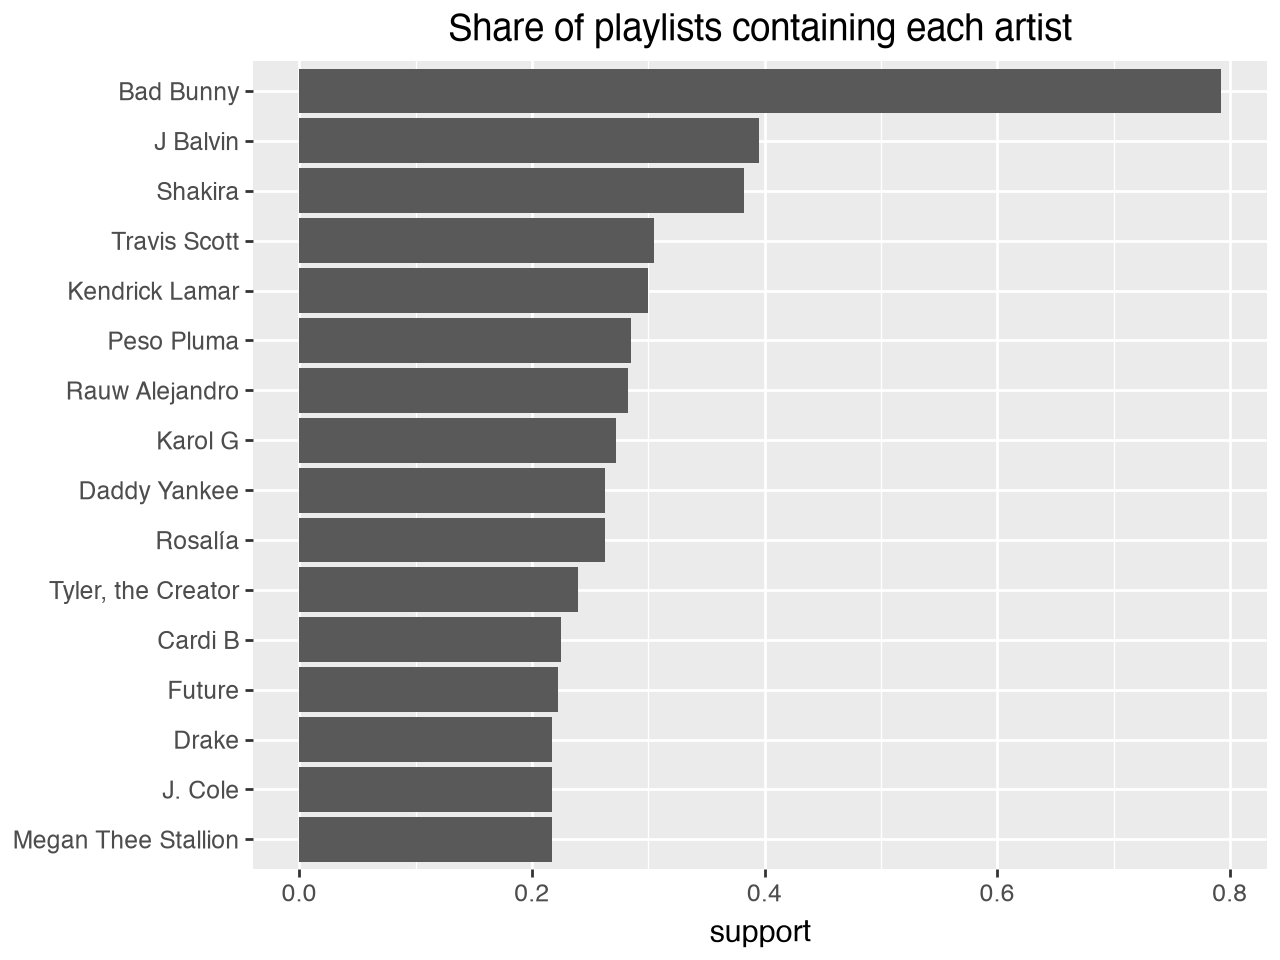

In [6]:
support_df = artist_support.reset_index()
support_df.columns = ["artist", "support"]
support_df["artist"] = pd.Categorical(support_df["artist"], categories=support_df["artist"][::-1])   # keep the order in the plot

(ggplot(support_df, aes(x="artist", y="support"))
 + geom_col()
 + coord_flip()
 + labs(title="Share of playlists containing each artist", x="", y="support"))

Support of a **set** of items = the share of baskets that contain **all** of them. `.all(axis=1)` asks, row by
row, "are all of these columns `True`?"

In [7]:
both = basket[["J. Cole", "Kendrick Lamar"]].all(axis=1)       # True only when BOTH are on the playlist
both.mean()

np.float64(0.1625)

✅ **Checkpoint 2.** (a) Which artist has the highest support, and roughly what share of playlists is that?
(b) Why is `basket[["J. Cole", "Kendrick Lamar"]].mean()` (no `.all`) *not* the support of the pair?

**Answer:** (a) **Bad Bunny**, at about **79 %** of all playlists — four in five. He was planted that way (added to 75 % of
playlists whatever the listener's taste), which makes him this data's "whole milk". (b) Without `.all`,
`.mean()` runs per column and returns *two* numbers — the support of each artist on its own. The support of
the pair needs one `True`/`False` per row ("both present?") first; that is what `.all(axis=1)` builds.

---
## 3. Confidence and lift: from "together" to "if … then …"

A rule **{A} → {B}** ("A is the *antecedent*, B the *consequent*") is scored with two numbers:

| Measure | Formula | Question it answers |
|---|---|---|
| **confidence** | support(A and B) ÷ support(A) | *Of the baskets with A, what share also have B?* |
| **lift** | support(A and B) ÷ [ support(A) × support(B) ] | *How many times more often than chance do A and B appear together?* |

Lift compares the observed co-occurrence with what independence would predict. **Lift ≈ 1** → no
relationship; **lift > 1** → A makes B more likely; **lift < 1** → A makes B *less* likely.

### Rule 1: {J. Cole} → {Kendrick Lamar}

In [8]:
s_cole = basket["J. Cole"].mean()
s_kendrick = basket["Kendrick Lamar"].mean()
s_both = basket[["J. Cole", "Kendrick Lamar"]].all(axis=1).mean()

confidence = s_both / s_cole
lift = s_both / (s_cole * s_kendrick)
print(f"support(J. Cole) = {s_cole:.3f}   support(Kendrick) = {s_kendrick:.3f}   support(both) = {s_both:.3f}")
print(f"confidence = {confidence:.3f}   lift = {lift:.2f}")

support(J. Cole) = 0.217   support(Kendrick) = 0.300   support(both) = 0.163
confidence = 0.747   lift = 2.49


### Rule 2: {Drake} → {Bad Bunny}

Same formulas, a very popular consequent:

In [9]:
s_drake = basket["Drake"].mean()
s_bunny = basket["Bad Bunny"].mean()
s_both2 = basket[["Drake", "Bad Bunny"]].all(axis=1).mean()

print(f"confidence = {s_both2 / s_drake:.3f}   lift = {s_both2 / (s_drake * s_bunny):.2f}")

confidence = 0.747   lift = 0.94


✅ **Checkpoint 3.** (a) In one sentence each, interpret the confidence and the lift of {J. Cole} → {Kendrick
Lamar} with the numbers. (b) Rule 2 has a respectable confidence but a lift close to 1. What does that
combination tell a streaming service? (c) Does the rule {Kendrick Lamar} → {J. Cole} have the same confidence?
The same lift? Why?

**Answer:** (a) *Confidence 0.747*: of the playlists that have J. Cole, about **three quarters** also have Kendrick Lamar.
*Lift 2.49*: that is about **2.5 times** the share of **all** playlists that have Kendrick (30 %) — the pair
occurs 2.5× more often than chance, exactly the planted pairing. (b) The two rules have the **same confidence,
0.747** — yet Rule 2's lift is **0.94**. Drake listeners include Bad Bunny about as often as *everyone* does
(79 %), slightly less in fact; the high confidence is only Bad Bunny's popularity. Recommending Bad Bunny
*because of* Drake adds nothing: lift ≈ 1 says "no information in this rule". Confidence alone cannot tell
these two rules apart; lift can. (c) The **lift is the same** (the formula is symmetric in A and B), but the
**confidence differs**: it divides by the support of the antecedent, and Kendrick is on more playlists (30 %)
than J. Cole (22 %), so {Kendrick} → {J. Cole} has a lower confidence (0.542). Direction matters for confidence;
it does not for lift.

---
## 4. Mining every rule at once: `apriori` and `association_rules`

With 16 artists there are already thousands of possible rules. `apriori` finds every **frequent itemset**
(every set of items whose support is at least `min_support`); `association_rules` then turns those itemsets
into rules and scores them. Two knobs:

- `min_support` — ignore combinations that are too rare to trust;
- a `metric` and `min_threshold` — keep only rules that score well enough (here: confidence ≥ 0.30).

In [10]:
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)
frequent_itemsets["n_items"] = frequent_itemsets["itemsets"].apply(len)
print(frequent_itemsets.shape)
frequent_itemsets.sort_values("support", ascending=False).head(8)

(198, 3)


,support,itemsets,n_items
0,0.7925,frozenset({Bad Bunny}),1
5,0.3950,frozenset({J Balvin}),1
13,0.3825,frozenset({Shakira}),1
20,0.3300,"frozenset({J Balvin, Bad Bunny})",2
14,0.3050,frozenset({Travis Scott}),1
28,0.3025,"frozenset({Shakira, Bad Bunny})",2
8,0.3000,frozenset({Kendrick Lamar}),1
10,0.2850,frozenset({Peso Pluma}),1


In [11]:
def make_rules(frequent_itemsets, min_confidence):
    """Association rules from frequent itemsets, keeping those with confidence >= min_confidence."""
    return association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

rules = make_rules(frequent_itemsets, 0.30)
print(len(rules), "rules")
rules.columns.tolist()

532 rules


['antecedents',
 'consequents',
 'antecedent support',
 'consequent support',
 'support',
 'confidence',
 'lift',
 'representativity',
 'leverage',
 'conviction',
 'zhangs_metric',
 'jaccard',
 'certainty',
 'kulczynski']

`antecedents` and `consequents` are frozensets — fine for the computer, hard to read. Keep the **simple rules** —
one artist on each side, the easiest to read and to act on — turn the sets into text, and keep the columns we
understand:

In [12]:
one_each_side = (rules["antecedents"].apply(len) == 1) & (rules["consequents"].apply(len) == 1)
rules = rules[one_each_side]
print(len(rules), "simple rules")
rules["antecedent"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["consequent"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
show = ["antecedent", "consequent", "support", "confidence", "lift"]

rules.sort_values("confidence", ascending=False)[show].head(8).round(3)

117 simple rules


,antecedent,consequent,support,confidence,lift
4,J Balvin,Bad Bunny,0.330,0.835,1.054
92,Karol G,Shakira,0.225,0.826,2.159
11,Rauw Alejandro,Bad Bunny,0.232,0.823,1.038
12,Rosalía,Bad Bunny,0.215,0.819,1.033
7,Karol G,Bad Bunny,0.220,0.807,1.019
10,Peso Pluma,Bad Bunny,0.228,0.798,1.007
13,Shakira,Bad Bunny,0.302,0.791,0.998
1,Daddy Yankee,Bad Bunny,0.208,0.790,0.997


In [13]:
rules.sort_values("lift", ascending=False)[show].head(8).round(3)

,antecedent,consequent,support,confidence,lift
77,J. Cole,Kendrick Lamar,0.162,0.747,2.490
78,Kendrick Lamar,J. Cole,0.162,0.542,2.490
62,Future,Travis Scott,0.165,0.742,2.431
63,Travis Scott,Future,0.165,0.541,2.431
92,Karol G,Shakira,0.225,0.826,2.159
91,Shakira,Karol G,0.225,0.588,2.159
22,Cardi B,J Balvin,0.158,0.700,1.772
21,J Balvin,Cardi B,0.158,0.399,1.772


✅ **Checkpoint 4.** (a) What do most of the highest-**confidence** rules have in common, and why is that a
trap? (b) What kinds of pairings rise to the top when you sort by **lift** instead? Do they match what was
planted in the simulation? (c) Find the cross-genre rule involving **Cardi B**. What are its confidence and
lift, and how would you explain it to a non-technical manager?

**Answer:** (a) Seven of the eight shown have the consequent **Bad Bunny**, with confidence 0.79 – 0.84 and **lift 0.99 – 1.05**.
Any antecedent "predicts" an artist who is on four of five playlists, so confidence looks great while lift sits
at 1 — these rules are popularity, not association. (The one exception in the list, Karol G → Shakira, is a
planted pair: confidence 0.83 *and* lift 2.16.) Sorting by confidence alone is the "popular items co-occur by
chance" trap that PA 7.1 asks about. (b) The planted pairs, each in both directions with the same lift:
**J. Cole ↔ Kendrick Lamar 2.49, Future ↔ Travis Scott 2.43, Karol G ↔ Shakira 2.16, Cardi B ↔ J Balvin 1.77**,
followed by mild within-hip-hop pairings (lift ≈ 1.4 – 1.7) created by shared taste. Yes — the method recovered
exactly what was planted, which is the point of simulating. (c) **{Cardi B} → {J Balvin}**: confidence **0.70**,
lift **1.77** — compare {Cardi B} → {Bad Bunny}, confidence 0.77 but lift 0.97. To a manager: *"Seven in ten
listeners who play Cardi B also play J Balvin — about 1.8 times the rate for listeners overall. That is a genuine
cross-genre link worth a joint recommendation; the Bad Bunny number looks higher but is just his popularity."*
(Say that the data is simulated; in the real world the two did record *I Like It* together, with Bad Bunny.)

---
## The four lines to keep

| | |
|---|---|
| **Baskets** | list of lists → `explode` → `pd.crosstab(id, item) > 0`: one row per basket, one `True`/`False` column per item |
| **Support** | `basket["A"].mean()` for one item; `basket[["A", "B"]].all(axis=1).mean()` for a set |
| **Confidence & lift** | confidence = supp(A,B) / supp(A); lift = supp(A,B) / (supp(A) · supp(B)); lift ≈ 1 means "no relationship" |
| **Mining** | `apriori(basket, min_support=…, use_colnames=True)` → `association_rules(…, metric="confidence", min_threshold=…)`; **sort by lift, check support** |

PA 7.1 (the groceries data) is on the course site: [https://gato365.github.io/gsb5544_instructor_learn_prep/](https://gato365.github.io/gsb5544_instructor_learn_prep/).